In [1]:
import pandas as pd

In [2]:
# download imbd_1000 movie data
url = "https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/imdb_1000.csv"
movies = pd.read_csv(url)

In [3]:
movies.head()

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."


Common data types are floats (numerical values), int (integer values), object (Python strings)

In [4]:
# data types in my data frame
movies.dtypes

star_rating       float64
title              object
content_rating     object
genre              object
duration            int64
actors_list        object
dtype: object

## Exploring a non-numeric column (object, int)

.unique() = returns unique values

.nunique() = returns number of unique values

.value_counts() = counts of unique values

.describe() = description of the non-numeric data

In [5]:
movies.content_rating.unique() # non-numeric columns

array(['R', 'PG-13', 'NOT RATED', 'PG', 'UNRATED', 'APPROVED', 'PASSED',
       'G', 'X', nan, 'TV-MA', 'GP', 'NC-17'], dtype=object)

In [6]:
movies.content_rating.nunique()

12

In [7]:
movies.content_rating.value_counts()

R            460
PG-13        189
PG           123
NOT RATED     65
APPROVED      47
UNRATED       38
G             32
PASSED         7
NC-17          7
X              4
GP             3
TV-MA          1
Name: content_rating, dtype: int64

In [8]:
movies.content_rating.value_counts(normalize=True) # return the proportion of each unique non-numeric values

R            0.471311
PG-13        0.193648
PG           0.126025
NOT RATED    0.066598
APPROVED     0.048156
UNRATED      0.038934
G            0.032787
PASSED       0.007172
NC-17        0.007172
X            0.004098
GP           0.003074
TV-MA        0.001025
Name: content_rating, dtype: float64

In [9]:
movies.content_rating.value_counts().head(3) # print the top three unique non-numneric values

R        460
PG-13    189
PG       123
Name: content_rating, dtype: int64

<AxesSubplot:>

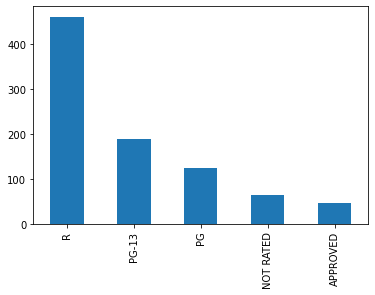

In [10]:
movies.content_rating.value_counts().head(5).plot.bar()

In [11]:
movies.content_rating.describe()

count     976
unique     12
top         R
freq      460
Name: content_rating, dtype: object

In [12]:
# explore multiple columns
movies[['content_rating','genre']].describe()

,content_rating,genre
count,976,979
unique,12,16
top,R,Drama
freq,460,278


## Exploring a numeric column

In [13]:
movies.duration

0      142
1      175
2      200
3      152
4      154
      ... 
974    116
975    118
976    138
977    114
978    126
Name: duration, Length: 979, dtype: int64

In [14]:
# mean movie duration
movies.duration.mean()

120.97957099080695

In [15]:
# longest movie duration
movies.duration.max()

242

In [16]:
# shortest movie duration
movies.duration.min()

64

In [17]:
# standard deviation
movies.duration.std()

26.218009846412112

In [18]:
# sum
movies.duration.sum()

118439

In [19]:
# calculate multiple statistics. aggregate function
movies.duration.agg(['max','min','mean'])

max     242.000000
min      64.000000
mean    120.979571
Name: duration, dtype: float64

you can write custom functions with pandas

In [20]:
# a function that calculates the difference between the max and the min value
def gap

SyntaxError: invalid syntax (<ipython-input-20-e8b3986c6145>, line 2)

In [21]:
# read the UFO data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/ufo.csv'
ufo = pd.read_csv(url)

In [22]:
ufo['Time'] = pd.to_datetime(ufo.Time)

In [23]:
ufo.dtypes

City                       object
Colors Reported            object
Shape Reported             object
State                      object
Time               datetime64[ns]
dtype: object

In [43]:
ufo.Time

0       1930-06-01 22:00:00
1       1930-06-30 20:00:00
2       1931-02-15 14:00:00
3       1931-06-01 13:00:00
4       1933-04-18 19:00:00
                ...        
18236   2000-12-31 23:00:00
18237   2000-12-31 23:00:00
18238   2000-12-31 23:45:00
18239   2000-12-31 23:45:00
18240   2000-12-31 23:59:00
Name: Time, Length: 18241, dtype: datetime64[ns]

In [28]:
ufo.Time.dt.dayofweek

0        6
1        0
2        6
3        0
4        1
        ..
18236    6
18237    6
18238    6
18239    6
18240    6
Name: Time, Length: 18241, dtype: int64

### Trick 1: filter by data (more on filtering later

In [31]:
ts = pd.to_datetime('1/1/1999')

In [35]:
ufo.loc[ufo.Time>=ts]

,City,Colors Reported,Shape Reported,State,Time
12832,Loma Rica,NaN,LIGHT,CA,1999-01-01 02:30:00
12833,Bauxite,NaN,NaN,AR,1999-01-01 03:00:00
12834,Florence,NaN,CYLINDER,SC,1999-01-01 14:00:00
12835,Lake Henshaw,NaN,CIGAR,CA,1999-01-01 15:00:00
12836,Wilmington Island,NaN,LIGHT,GA,1999-01-01 17:15:00
...,...,...,...,...,...
18236,Grant Park,NaN,TRIANGLE,IL,2000-12-31 23:00:00
18237,Spirit Lake,NaN,DISK,IA,2000-12-31 23:00:00
18238,Eagle River,NaN,NaN,WI,2000-12-31 23:45:00
18239,Eagle River,RED,LIGHT,WI,2000-12-31 23:45:00


### Trick 2: performing math operations with dates

In [41]:
timer = ufo.Time.max()-ufo.Time.min()
timer

Timedelta('25781 days 01:59:00')

In [42]:
timer.days

25781

In [45]:
# extra: plot number of ufos reported by year

ufo['year'] = ufo.Time.dt.year

In [46]:
ufo

,City,Colors Reported,Shape Reported,State,Time,year
0,Ithaca,NaN,TRIANGLE,NY,1930-06-01 22:00:00,1930
1,Willingboro,NaN,OTHER,NJ,1930-06-30 20:00:00,1930
2,Holyoke,NaN,OVAL,CO,1931-02-15 14:00:00,1931
3,Abilene,NaN,DISK,KS,1931-06-01 13:00:00,1931
4,New York Worlds Fair,NaN,LIGHT,NY,1933-04-18 19:00:00,1933
...,...,...,...,...,...,...
18236,Grant Park,NaN,TRIANGLE,IL,2000-12-31 23:00:00,2000
18237,Spirit Lake,NaN,DISK,IA,2000-12-31 23:00:00,2000
18238,Eagle River,NaN,NaN,WI,2000-12-31 23:45:00,2000
18239,Eagle River,RED,LIGHT,WI,2000-12-31 23:45:00,2000


<AxesSubplot:>

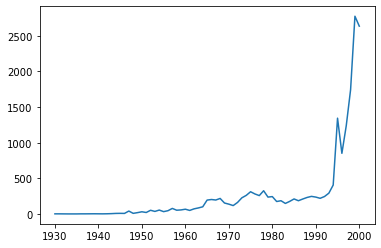

In [52]:
ufo.year.value_counts().sort_index().plot()

## working with strings

In [54]:
# load the Chipotle dataset
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/chipotleorders.csv'
orders = pd.read_csv(url)

In [55]:
orders

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


In [57]:
# working with strings
'hello'

'hello'

In [58]:
'hello'.upper()

'HELLO'

In [59]:
'HELLO'.lower()

'hello'

In [63]:
"hello, my name is Javier".split(' ')[1]

'my'

In [64]:
"hello, my name is Javier".replace('Javier', 'Bob')

'hello, my name is Bob'

In [65]:
orders.item_name

0                Chips and Fresh Tomato Salsa
1                                        Izze
2                            Nantucket Nectar
3       Chips and Tomatillo-Green Chili Salsa
4                                Chicken Bowl
                        ...                  
4617                            Steak Burrito
4618                            Steak Burrito
4619                       Chicken Salad Bowl
4620                       Chicken Salad Bowl
4621                       Chicken Salad Bowl
Name: item_name, Length: 4622, dtype: object

In [66]:
orders.item_name.str.upper()

0                CHIPS AND FRESH TOMATO SALSA
1                                        IZZE
2                            NANTUCKET NECTAR
3       CHIPS AND TOMATILLO-GREEN CHILI SALSA
4                                CHICKEN BOWL
                        ...                  
4617                            STEAK BURRITO
4618                            STEAK BURRITO
4619                       CHICKEN SALAD BOWL
4620                       CHICKEN SALAD BOWL
4621                       CHICKEN SALAD BOWL
Name: item_name, Length: 4622, dtype: object

In [67]:
orders.item_name.str.contains('Chicken')

0       False
1       False
2       False
3       False
4        True
        ...  
4617    False
4618    False
4619     True
4620     True
4621     True
Name: item_name, Length: 4622, dtype: bool

In [69]:
orders.loc[orders.item_name.str.contains('Chicken')]

,order_id,quantity,item_name,choice_description,item_price
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
11,6,1,Chicken Crispy Tacos,"[Roasted Chili Corn Salsa, [Fajita Vegetables,...",$8.75
12,6,1,Chicken Soft Tacos,"[Roasted Chili Corn Salsa, [Rice, Black Beans,...",$8.75
13,7,1,Chicken Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",$11.25
...,...,...,...,...,...
4604,1828,1,Chicken Bowl,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees...",$8.75
4615,1832,1,Chicken Soft Tacos,"[Fresh Tomato Salsa, [Rice, Cheese, Sour Cream]]",$8.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75
